# LLM-Augmented Test Analysis - Interactive Demo

This notebook demonstrates all features available in the Streamlit UI (`app_llm_demo.py`), adapted for Jupyter.

**Features (matching Streamlit UI):**
- **Chat Analysis** — Ask questions in natural language with MCP tool integration
- **Deep Dive** — Analyze specific tests with classifier prediction + LLM insights
- **Baseline Comparison** — Compare test results against baseline performance
- **Report Generation** — PO Sign-Off, Dev/QA, Stakeholder, Summary reports (anti-hallucination)
- **Test Comparison** — Compare two tests side-by-side with predictions
- **Visualizations** — Charts with LLM interpretation

**Setup:** The notebook automatically uses academic mode (Excel data). If your OpenAI API key isn't in `.env`, you'll be prompted to enter it when you run the first cell.

In [2]:
# Setup - Run this first
import sys
from pathlib import Path
import os

# Ensure we're in the project root directory (not notebooks/)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"📂 Working directory: {os.getcwd()}")

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

# Default to academic mode BEFORE loading .env (so notebook always uses academic)
os.environ['LLM_MODE'] = 'academic'

# Load environment
from dotenv import load_dotenv
load_dotenv(Path('.env'))

# Academic mode requires OpenAI API key - check if set and prompt if needed
if not os.getenv('OPENAI_API_KEY'):
    print("\n⚠️  Academic mode requires OpenAI API key")
    print("    You can either:")
    print("    1. Add OPENAI_API_KEY=your-key-here to your .env file, or")
    print("    2. Enter it below (will be stored for this session only)\n")
    
    from getpass import getpass
    api_key = getpass("Enter your OpenAI API key: ")
    if api_key:
        os.environ['OPENAI_API_KEY'] = api_key
        print("✅ API key set for this session")
    else:
        print("❌ No API key provided - LLM features will not work")

# Import our components
from src.analyzer import TestAnalyzer
from src.data_source import get_data_source
from src.llm_provider import get_llm_provider

# Import centralized prompts (same as Streamlit UI)
from prompts.report_prompts import (
    get_summary_prompt_with_data,
    get_po_report_prompt_with_data,
    get_dev_report_prompt_with_data,
    get_stakeholder_report_prompt_with_data,
    get_test_comparison_prompt,
    format_critical_transactions_list,
    format_transaction_table,
    format_qa_table
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Setup complete!")
print(f"   Mode: {os.getenv('LLM_MODE')}")
print("   📝 Note: Notebook always uses academic mode (Excel data)")


📂 Working directory: /Users/sailaw864@cable.comcast.com/Desktop/Drexel/INFO629/Assignments/A3_Code

⚠️  Academic mode requires OpenAI API key
    You can either:
    1. Add OPENAI_API_KEY=your-key-here to your .env file, or
    2. Enter it below (will be stored for this session only)

✅ API key set for this session
✅ Setup complete!
   Mode: academic
   📝 Note: Notebook always uses academic mode (Excel data)


## 1. Initialize Components

Load the TestAnalyzer, data source, and LLM provider.

In [3]:
# Initialize analyzer (combines data + LLM + classifier)
analyzer = TestAnalyzer()

# Direct access to components
data_source = analyzer.data_source
llm = analyzer.llm
model = analyzer.model

print("✅ TestAnalyzer initialized")
print(f"   Data source: {data_source.__class__.__name__}")
print(f"   LLM: {llm.__class__.__name__}")
print(f"   Classifier: {model.__class__.__name__}")

🔧 Initializing TestAnalyzer in ACADEMIC mode...
🎓 Initializing ACADEMIC mode (OpenAI GPT-4)
   ✅ LLM: OpenAIProvider
🎓 Initializing ACADEMIC mode (Excel data source)
   ✅ Data: ExcelDataSource
   ✅ Classifier: RandomForestClassifier
✅ TestAnalyzer ready

✅ TestAnalyzer initialized
   Data source: ExcelDataSource
   LLM: OpenAIProvider
   Classifier: RandomForestClassifier


## 2. Load and Explore Data

Get an overview of available tests.

In [5]:
# Load all test data
df = data_source.load_test_data()

print(f"📊 Dataset Overview:")
print(f"   Total rows: {len(df):,}")
print(f"   Unique tests: {df['testplan'].nunique()}")
print(f"   Unique transactions: {df['transaction_name'].nunique()}")
print(f"   Date range: {df['end_time'].min()} to {df['end_time'].max()}")
print(f"\n   Exit codes: {sorted(df['exit_code'].unique())}")

# Show sample
df.head()

📂 Loading data from academic_demo_data.xlsx...
✅ Loaded 15060 rows, 299 unique tests
📊 Dataset Overview:
   Total rows: 15,060
   Unique tests: 299
   Unique transactions: 105
   Date range: 2022-09-15 14:23:56.976405-07:00 to 2026-02-27 05:46:14.138698-08:00

   Exit codes: [np.int64(1), np.int64(2), np.int64(3)]


,testplan,run_id,transaction_name,request_type,txn_requests,txn_failed,error_percentage,avg_response_time,min_response_time,max_response_time,median_response_time,perc_95,perc_99,exit_code,num_clients,rps_avg,resp_time_avg,fail_ratio,build_version,total_requests,end_time,test_type,result
0,LoadTest_001,2026-02-27 04:46:11.914572-08:00,API_001,POST,1509,1,0.066269,128.009650,12.088213,20022.279826,76.354736,281.179033,672.237139,1,2000,794.988983,62.549452,0.000741,v2.6,2860163,2026-02-27 05:46:14.138698-08:00,load_test,UNKNOWN
1,LoadTest_001,2026-02-27 04:46:11.914572-08:00,API_002,POST,1159,1,0.086281,123.394533,10.761668,20019.217129,76.256045,307.458138,727.905713,1,2000,794.988983,62.549452,0.000741,v2.6,2860163,2026-02-27 05:46:14.138698-08:00,load_test,UNKNOWN
2,LoadTest_001,2026-02-27 04:46:11.914572-08:00,API_003,POST,401,0,0.000000,115.014525,10.663359,2842.885032,76.240990,307.555818,854.773185,1,2000,794.988983,62.549452,0.000741,v2.6,2860163,2026-02-27 05:46:14.138698-08:00,load_test,UNKNOWN
3,LoadTest_001,2026-02-27 04:46:11.914572-08:00,API_004,POST,3520,4,0.113636,174.520850,11.074679,133791.521409,75.306639,271.015443,706.148187,1,2000,794.988983,62.549452,0.000741,v2.6,2860163,2026-02-27 05:46:14.138698-08:00,load_test,UNKNOWN
4,LoadTest_001,2026-02-27 04:46:11.914572-08:00,API_005,POST,9922,0,0.000000,47.096822,30.428410,12167.969970,40.434238,70.614239,102.414100,1,2000,794.988983,62.549452,0.000741,v2.6,2860163,2026-02-27 05:46:14.138698-08:00,load_test,UNKNOWN


In [6]:
# Get test summary
test_summary = df.groupby(['testplan', 'exit_code']).agg({
    'transaction_name': 'count',
    'error_percentage': 'mean',
    'perc_95': 'mean',
    'avg_response_time': 'mean'
}).rename(columns={'transaction_name': 'num_transactions'})

test_summary = test_summary.reset_index()
test_summary['result'] = test_summary['exit_code'].map({1: 'PASS', 2: 'FAIL', 3: 'FAIL', 4: 'FAIL'})

print("📋 Test Summary:")
print(test_summary.head(10))

📋 Test Summary:
       testplan  exit_code  num_transactions  error_percentage       perc_95  \
0  LoadTest_001          1                54          0.064443    720.813111   
1  LoadTest_002          1                54          2.662994  63364.474189   
2  LoadTest_003          1                54          0.006933    648.030754   
3  LoadTest_004          1                54          0.026397    754.703175   
4  LoadTest_005          1                54          0.016856    693.703098   
5  LoadTest_006          1                54          0.067323    701.005846   
6  LoadTest_007          1                57          5.269454    831.603301   
7  LoadTest_008          1                54          0.042405    786.183206   
8  LoadTest_009          1                54          0.000371    810.813596   
9  LoadTest_010          1                55          1.829408    640.857953   

   avg_response_time result  
0         480.239514   PASS  
1        6837.431908   PASS  
2         440

## 3. Interactive Q&A with MCP Tool Integration

The `analyzer.ask()` method automatically routes questions to MCP tools (query_tests, get_test_details, compare_baseline, predict_test) and fetches real data before sending to LLM.

This is the same unified method used by the Streamlit UI.

In [7]:
# Conversation history (shared across all helpers)
conversation_history = []

def ask_question(question: str):
    """
    Ask a question about test data using MCP tool integration.
    Same as the Chat Analysis page in Streamlit UI.
    
    Automatically:
    - Routes to MCP tools (query_tests, get_test_details, etc.)
    - Fetches real data from database
    - Maintains conversation context
    
    Args:
        question: Your question in natural language
    
    Examples:
        ask_question("What are the last 5 test runs?")
        ask_question("Show me all failed tests")
        ask_question("What is the overall pass rate?")
    """
    print(f"🤔 Question: {question}")
    print("   🤖 Processing with MCP tools...")
    
    result = analyzer.ask(
        question,
        conversation_history=conversation_history
    )
    
    answer = result['answer']
    tools_used = result.get('tools_used', [])
    tokens = result.get('tokens_used', 'N/A')
    
    # Save to history
    conversation_history.append((question, answer))
    
    # Display
    print(f"\n💡 Answer:")
    print(answer)
    
    if tools_used:
        print(f"\n   🔧 Tools used: {', '.join(tools_used)}")
    print(f"   💭 Tokens: {tokens}")
    print(f"   📝 Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return answer

print("✅ ask_question() loaded — uses analyzer.ask() with MCP tool integration")
print("\nExamples:")
print('   ask_question("What are the last 5 test runs?")')
print('   ask_question("Show me all failed tests")')
print('   ask_question("What is the overall pass rate?")')

✅ ask_question() loaded — uses analyzer.ask() with MCP tool integration

Examples:
   ask_question("What are the last 5 test runs?")
   ask_question("Show me all failed tests")
   ask_question("What is the overall pass rate?")


In [8]:
# Helper to ask about a specific test (anti-hallucination: fetches real test data)
def ask_about_test(test_id_or_index, question):
    """
    Ask a question about a specific test.
    Uses analyzer.ask(about_test=...) which fetches real test data
    to prevent LLM hallucination — same as Deep Dive in Streamlit UI.
    
    Args:
        test_id_or_index: Test index (0-N) or testplan ID string
        question: Your question about the test
    
    Example:
        ask_about_test(0, "What are the slowest transactions?")
        ask_about_test("LoadTest_20260304T060726Z", "Why did this test fail?")
    """
    print(f"🔍 Analyzing test: {test_id_or_index}")
    print(f"🤔 Question: {question}")
    print("   🤖 Fetching real test data + sending to LLM...")
    
    result = analyzer.ask(
        question,
        about_test=test_id_or_index,
        conversation_history=conversation_history
    )
    
    answer = result['answer']
    tokens = result.get('tokens_used', 'N/A')
    
    # Save to history
    conversation_history.append((question, answer))
    
    # Display
    print(f"\n💡 Answer:")
    print(answer)
    print(f"\n   💭 Tokens: {tokens}")
    print(f"   📝 Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return answer

print("✅ ask_about_test() loaded — uses analyzer.ask(about_test=...) with real data")
print("   Anti-hallucination: real test context is fetched before LLM sees the question")

✅ ask_about_test() loaded — uses analyzer.ask(about_test=...) with real data
   Anti-hallucination: real test context is fetched before LLM sees the question


In [10]:
# NEW: Helper for data-driven questions (like "last 3 tests", aggregations, etc.)
def ask_with_data(query_result, question):
    """
    Ask LLM to interpret pandas query results or any data.
    Uses analyzer.ask_about_data() - works in both Streamlit and Jupyter.
    
    Args:
        query_result: Pandas DataFrame, Series, or formatted string
        question: Your question about the data
    
    Example:
        # Get last 3 tests
        last_3 = df.groupby("testplan").agg({
            "end_time": "first",
            "exit_code": "first",
            "transaction_name": "count"
        }).sort_values("end_time", ascending=False).head(3)
        
        ask_with_data(last_3, "What are the last 3 test runs?")
    """
    # Convert DataFrame/Series to string if needed
    if hasattr(query_result, "to_string"):
        data_str = query_result.to_string()
    else:
        data_str = str(query_result)
    
    # Use analyzer's ask_about_data method
    result = analyzer.ask_about_data(
        data_context=data_str,
        question=question,
        conversation_history=conversation_history
    )
    
    # Display
    print(f"🤔 Question: {question}")
    print(f"\n💡 Answer:")
    print(result["answer"])
    print(f"\n   Tokens used: {result["tokens_used"] or 'N/A'}")
    
    # Save to history
    conversation_history.append((question, result["answer"]))
    print(f"   Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return result["answer"]

print("✅ ask_with_data() helper loaded!")
print("   Uses analyzer.ask_about_data() - works with any pandas query")
print("\nExamples:")
print("   last_3 = df.groupby('testplan')['end_time'].first().sort_values().tail(3)")
print("   ask_with_data(last_3, 'What are the last 3 test runs?')")


✅ ask_with_data() helper loaded!
   Uses analyzer.ask_about_data() - works with any pandas query

Examples:
   last_3 = df.groupby('testplan')['end_time'].first().sort_values().tail(3)
   ask_with_data(last_3, 'What are the last 3 test runs?')


## 4. Ask Your Questions!

Now you can ask questions interactively. MCP tools automatically fetch real data from the database.

```python
# MCP-powered queries (fetch real data automatically)
ask_question("What are the last 5 test runs?")
ask_question("Show me all failed tests")
ask_question("What is the overall pass rate?")

# Test-specific analysis (anti-hallucination with real data)
ask_about_test(0, "What are the slowest transactions?")
ask_about_test("LoadTest_20260304T060726Z", "Why did this test fail?")

# Data-driven analysis (pandas + LLM)
ask_with_data(df.describe(), "What patterns do you see in this data?")
```

In [11]:
# Example 1: MCP-powered query — fetches real test data from database
ask_question("What are the last 5 test runs and their results?")

🤔 Question: What are the last 5 test runs and their results?
   🤖 Processing with MCP tools...
🤔 Analyzing question: 'What are the last 5 test runs and their results?'
   ⚠️  Failed to parse tool selection, using fallback
   🔧 Calling query_tests({'limit': 5})
      ↳ Reusing data source connection (no new DB connection)

💡 Answer:
The last 5 test runs and their results are summarized in the table below:

| Test ID      | P95 Response Time | Error Rate | Transactions (Txns) | Result | Timestamp                     |
|--------------|-------------------|------------|---------------------|--------|-------------------------------|
| LoadTest_001 | 721ms             | 0.1%       | 54                  | PASS   | 2026-02-27 05:46:14.138698-08:00 |
| LoadTest_002 | 63364ms           | 2.7%       | 54                  | PASS   | 2026-02-25 23:11:45.532796-08:00 |
| LoadTest_003 | 648ms             | 0.0%       | 54                  | PASS   | 2026-02-23 23:07:31.374277-08:00 |
| LoadTest_004 | 

"The last 5 test runs and their results are summarized in the table below:\n\n| Test ID      | P95 Response Time | Error Rate | Transactions (Txns) | Result | Timestamp                     |\n|--------------|-------------------|------------|---------------------|--------|-------------------------------|\n| LoadTest_001 | 721ms             | 0.1%       | 54                  | PASS   | 2026-02-27 05:46:14.138698-08:00 |\n| LoadTest_002 | 63364ms           | 2.7%       | 54                  | PASS   | 2026-02-25 23:11:45.532796-08:00 |\n| LoadTest_003 | 648ms             | 0.0%       | 54                  | PASS   | 2026-02-23 23:07:31.374277-08:00 |\n| LoadTest_004 | 755ms             | 0.0%       | 54                  | PASS   | 2026-02-17 05:49:20.916271-08:00 |\n| LoadTest_005 | 694ms             | 0.0%       | 54                  | PASS   | 2026-02-16 23:07:34.427394-08:00 |\n\nKey observations from these results:\n- **Consistent Transaction Volume**: Each test executed 54 transactio

In [12]:
# Example 2: Ask about failures — MCP tools fetch failure data automatically
ask_question("What patterns do you see in failed tests?")

🤔 Question: What patterns do you see in failed tests?
   🤖 Processing with MCP tools...
🤔 Analyzing question: 'What patterns do you see in failed tests?'
   ⚠️  Failed to parse tool selection, using fallback
   🔧 Calling query_tests({'limit': 5})
      ↳ Reusing data source connection (no new DB connection)

💡 Answer:
Based on the provided data, there are no failed tests among the last 5 test runs shared; all are marked as PASS. However, we can still analyze the provided data for potential patterns that could indicate issues worth investigating, particularly focusing on LoadTest_002, which, despite being marked as PASS, shows concerning performance metrics.

**Observations from the provided data:**
- **No Failed Tests**: Each test listed has a Result of PASS, indicating no failures according to the test criteria set for these runs.
- **High Variability in Response Times**: The P95 response time for LoadTest_002 is significantly higher (63364ms) than for the other tests, which range fro

"Based on the provided data, there are no failed tests among the last 5 test runs shared; all are marked as PASS. However, we can still analyze the provided data for potential patterns that could indicate issues worth investigating, particularly focusing on LoadTest_002, which, despite being marked as PASS, shows concerning performance metrics.\n\n**Observations from the provided data:**\n- **No Failed Tests**: Each test listed has a Result of PASS, indicating no failures according to the test criteria set for these runs.\n- **High Variability in Response Times**: The P95 response time for LoadTest_002 is significantly higher (63364ms) than for the other tests, which range from 648ms to 755ms. This kind of variability, especially with such a high response time, could potentially lead to user dissatisfaction, even though it didn't result in a test marked as FAIL.\n- **Error Rates**: LoadTest_002 also has a notably higher error rate (2.7%) compared to the other tests, which have 0.0% or 

In [13]:
# Example 3: Test-specific analysis (anti-hallucination: real data is fetched)
ask_about_test(0, "What are the slowest transactions and why might they be slow?")

🔍 Analyzing test: 0
🤔 Question: What are the slowest transactions and why might they be slow?
   🤖 Fetching real test data + sending to LLM...
📊 Loaded baselines from baselines_anonymized.pkl (academic mode)
  ℹ️  Using existing test_type column from data

💡 Answer:
The data provided highlights several transactions with notably high response times, particularly when looking at the P95 response times. The slowest transactions, based on P95 response times, are:

1. **Auth_001**
   - P95: 2030.28 ms
   - Error Rate: 0.66%
   - Deviation from Baseline P95: +7.0%

2. **Service_005**
   - P95: 2027.25 ms
   - Error Rate: 0.26%
   - Deviation from Baseline P95: +6.8%

3. **Service_001**
   - P95: 2021.89 ms
   - Error Rate: 0.00%
   - Deviation from Baseline P95: +6.1%

These transactions demonstrate significantly higher response times, indicating potential areas of concern within the application's performance. Several factors could contribute to why these transactions are notably slower, inc

"The data provided highlights several transactions with notably high response times, particularly when looking at the P95 response times. The slowest transactions, based on P95 response times, are:\n\n1. **Auth_001**\n   - P95: 2030.28 ms\n   - Error Rate: 0.66%\n   - Deviation from Baseline P95: +7.0%\n\n2. **Service_005**\n   - P95: 2027.25 ms\n   - Error Rate: 0.26%\n   - Deviation from Baseline P95: +6.8%\n\n3. **Service_001**\n   - P95: 2021.89 ms\n   - Error Rate: 0.00%\n   - Deviation from Baseline P95: +6.1%\n\nThese transactions demonstrate significantly higher response times, indicating potential areas of concern within the application's performance. Several factors could contribute to why these transactions are notably slower, including:\n\n- **Resource Intensive Operations**: They might involve complex database queries, large data processing, or interactions with external systems that are resource-intensive and increase the response time.\n- **Concurrency and Load Issues**:

## 5. Deep Dive: Analyze Specific Test

Pick a test and get comprehensive analysis — same as the **Deep Dive** page in the Streamlit UI.

Uses `analyzer.analyze_test()` which fetches real test data to prevent hallucination.

In [14]:
# List available tests with their results
tests = data_source.list_tests(limit=20)
print("Available tests:")
for i, test in enumerate(tests[:10], 1):
    result = df[df['testplan'] == test]['exit_code'].iloc[0]
    result_str = "✅ PASS" if result == 1 else "❌ FAIL"
    print(f"  {i}. {test} — {result_str}")

if len(tests) > 10:
    print(f"  ... and {len(tests) - 10} more")

print("\nTo analyze: analyzer.analyze_test('TEST_ID_HERE')")
print("To ask about: ask_about_test(0, 'What are the key findings?')")

Available tests:
  1. LoadTest_001 — ✅ PASS
  2. LoadTest_002 — ✅ PASS
  3. LoadTest_003 — ✅ PASS
  4. LoadTest_004 — ✅ PASS
  5. LoadTest_005 — ✅ PASS
  6. LoadTest_006 — ✅ PASS
  7. LoadTest_007 — ✅ PASS
  8. LoadTest_008 — ✅ PASS
  9. LoadTest_009 — ✅ PASS
  10. LoadTest_010 — ✅ PASS
  ... and 10 more

To analyze: analyzer.analyze_test('TEST_ID_HERE')
To ask about: ask_about_test(0, 'What are the key findings?')


In [15]:
# Deep dive analysis on a specific test
test_to_analyze = tests[0]  # Change index or use specific ID
print(f"🔍 Deep Dive: {test_to_analyze}\n")

# Full LLM analysis (same as Streamlit Deep Dive page)
analysis = analyzer.analyze_test(test_to_analyze, include_transactions=True)
print(analysis)

# Follow-up question about this test
ask_about_test(test_to_analyze, "What is the most concerning finding and what should we investigate?")

🔍 Deep Dive: LoadTest_001

🔍 Analyzing test: LoadTest_001

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading anonymized baselines (academic mode)...
  ✅ Loaded 179 baseline groups
     Sanitized transactions: 103

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
📊 Loaded baselines from baselines_anonymized.pkl (academic mode)
  ℹ️  Using existing test_type column from data
   🤖 Querying LLM for analysis...
   ✅ Analysis complete (5296 tokens)

## Overall Assessment:

- **Verdict**: PASS (With Concerns)
- **Classifier Confidence**: 99.5%
- **Summary of Baseline Comparison**:
  - **Critical Deviations**: 11 transactions showed critical deviations in either P95 or Avg RT metrics, with 3 transactions exceeding the 50% threshold for P95 and 8 transactions for Avg RT.
  - **Degraded Transactions**: 12 tr

"The most concerning findings from LoadTest_001 relate to significant deviations in performance metrics compared to the historical baseline, particularly in terms of P95 response times and average response times, along with non-zero error rates for certain transactions. Here's a focused analysis on these aspects:\n\n1. **Significant Deviations in P95 Response Times and Average Response Times:**\n   - Transactions like **API_016**, **API_017**, and **API_014** show critical deviations in P95 response times (up to +194.5%) and average response times (up to +94.5%) from the baseline. Such deviations indicate severe performance degradations and are likely to negatively impact user experience. The large increase in response time suggests that these endpoints might be facing bottlenecks under load conditions, such as database locks, inefficient queries, or resource contention issues.\n\n2. **High Average Response Time with Lower P95 Deviation:**\n   - **API_025** shows a peculiar case where 

## 6. Compare Tests

Compare two tests to understand differences — same as the **Compare Tests** page in Streamlit UI.

Two comparison methods available:
1. **analyzer.compare_tests()** — High-level comparison using LLM
2. **get_test_comparison_prompt()** — Focused comparison with top performers and common transaction analysis (optimized to avoid timeout)


In [17]:
# Find a PASS and FAIL test for comparison
# Get all unique tests with their exit codes
test_samples = df.groupby('testplan')['exit_code'].first().reset_index()
pass_tests = test_samples[test_samples['exit_code'] == 1]['testplan'].tolist()
fail_tests = test_samples[test_samples['exit_code'] != 1]['testplan'].tolist()

pass_test = pass_tests[0] if pass_tests else None
fail_test = fail_tests[0] if fail_tests else None

print(f"PASS test: {pass_test}")
print(f"FAIL test: {fail_test}")
print(f"\nAvailable: {len(pass_tests)} PASS tests, {len(fail_tests)} FAIL tests")

PASS test: LoadTest_001
FAIL test: LoadTest_032

Available: 150 PASS tests, 149 FAIL tests


In [18]:
# Method 1: Simple comparison using analyzer.compare_tests()
if pass_test and fail_test:
    comparison = analyzer.compare_tests(pass_test, fail_test)
    print("=" * 80)
    print("METHOD 1: High-Level Comparison")
    print("=" * 80)
    print(comparison)
    print()
else:
    print("Need both PASS and FAIL tests for comparison")


🔍 Comparing tests:
   Test 1: LoadTest_001
   Test 2: LoadTest_032

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading anonymized baselines (academic mode)...
  ✅ Loaded 179 baseline groups
     Sanitized transactions: 103

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading anonymized baselines (academic mode)...
  ✅ Loaded 179 baseline groups
     Sanitized transactions: 103

Step 3: Computing per-transaction % deviations...
  1 transaction rows have no baseline (appear only in failing runs)

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 0  Fail: 1
   🤖 Querying LLM for comparison...
   ✅ Comparison complete (940 tokens)

In [19]:
# Method 2: Optimized comparison with focused transaction data
# Uses get_test_comparison_prompt() from prompts/report_prompts.py
# Shows: top 10 slowest, common transaction regressions/improvements
# Optimized to avoid timeout by focusing on key insights instead of ALL transactions

if pass_test and fail_test:
    # Get test data
    df_test1 = analyzer.data_source.get_test_by_id(pass_test)
    df_test2 = analyzer.data_source.get_test_by_id(fail_test)
    
    # Build optimized comparison prompt
    comparison_prompt = get_test_comparison_prompt(
        pass_test, fail_test, df_test1, df_test2
    )
    
    # Send to LLM
    print("=" * 80)
    print("METHOD 2: Optimized Focused Comparison")
    print("=" * 80)
    result = analyzer.ask(comparison_prompt, conversation_history=conversation_history)
    print(result['answer'])
    print(f"\n   💭 Tokens: {result.get('tokens_used', 'N/A')}")
    conversation_history.append((f"Compare {pass_test} vs {fail_test}", result['answer']))
else:
    print("Need both PASS and FAIL tests for comparison")


METHOD 2: Optimized Focused Comparison
🤔 Analyzing question: '# Test Comparison: LoadTest_001 vs LoadTest_032

## Summary Statistics

### Test...'
   💡 Tool plan: The user's question is a detailed analysis request comparing two specific tests, LoadTest_001 and LoadTest_032, focusing on overall performance, transaction-level patterns, root cause hypotheses, and actionable recommendations. Since the user has provided a comprehensive summary of both tests, including key statistics and transaction-level data, there is no immediate need to fetch new data using the available tools. The analysis requires synthesizing the provided information rather than retrieving additional data. Therefore, no tools need to be called at this stage.
### Overall Performance Winner

- **LoadTest_001** is the clear overall performance winner when compared to LoadTest_032. It demonstrated significantly lower P95 average response times (720.81 ms vs. 59885.60 ms), lower average response times (480.24 ms vs. 35071.

## 7. Baseline Comparison

Compare a test against the classifier's baseline data — shows how each transaction deviates from the
median of passing runs. Same data used by the ML classifier for feature engineering.

Uses `get_baseline_comparison()` from `mcp_server/tools/baseline.py`.

**Mode-Aware Loading:**
- **Academic Mode** (`LLM_MODE=academic`): Uses `baselines_anonymized.pkl` with sanitized transaction names (API_001, Auth_001, etc.)
- **Work Mode** (`LLM_MODE=work`): Uses `baselines.pkl` with original transaction names

The baseline tool automatically loads the correct file based on your environment.


In [21]:
from mcp_server.tools.baseline import get_baseline_comparison

# Compare latest test against baseline
test_for_baseline = tests[0]  # Change to any test ID
print(f"📊 Baseline Comparison: {test_for_baseline}\n")

baseline_result = get_baseline_comparison(test_for_baseline, analyzer=analyzer)

if 'error' in baseline_result:
    print(f"❌ {baseline_result['error']}")
else:
    summary = baseline_result['summary']
    print(f"Test Type: {summary['test_type']} | Clients: {summary['num_clients']} | Result: {summary['result']}")
    print(f"Transactions: {summary['total_transactions']} total, {summary['transactions_with_baseline']} with baseline")
    
    if 'avg_p95_deviation_pct' in summary:
        print(f"\n📈 Deviation Summary:")
        print(f"   Avg P95 deviation: {summary['avg_p95_deviation_pct']:.1f}%")
        print(f"   Max P95 deviation: {summary['max_p95_deviation_pct']:.1f}%")
        print(f"   Avg error delta:   {summary['avg_error_delta']:.2f}%")
        print(f"   Critical (>50%):   {summary.get('critical_deviations_count', 0)} txns")
        print(f"   Degraded (20-50%): {summary.get('degraded_deviations_count', 0)} txns")
    
    # Show worst deviations
    with_baseline = [t for t in baseline_result['transactions'] if t['has_baseline']]
    if with_baseline:
        worst = sorted(with_baseline, key=lambda t: abs(t['deviation']['p95_pct']), reverse=True)[:5]
        print(f"\n🔥 Top 5 Largest P95 Deviations:")
        for t in worst:
            dev = t['deviation']['p95_pct']
            arrow = "↑" if dev > 0 else "↓"
            print(f"   {t['name']}: {t['actual']['p95']:.0f}ms vs {t['baseline']['p95']:.0f}ms baseline ({arrow}{abs(dev):.1f}%)")

📊 Baseline Comparison: LoadTest_001

📊 Loaded baselines from baselines_anonymized.pkl (academic mode)
  ℹ️  Using existing test_type column from data
Test Type: load_test | Clients: 2000 | Result: PASS
Transactions: 54 total, 54 with baseline

📈 Deviation Summary:
   Avg P95 deviation: 7.5%
   Max P95 deviation: 194.5%
   Avg error delta:   0.06%
   Critical (>50%):   3 txns
   Degraded (20-50%): 5 txns

🔥 Top 5 Largest P95 Deviations:
   API_016: 826ms vs 281ms baseline (↑194.5%)
   API_017: 1258ms vs 436ms baseline (↑189.0%)
   API_014: 1092ms vs 619ms baseline (↑76.3%)
   Callback_008: 243ms vs 497ms baseline (↓51.1%)
   Callback_007: 249ms vs 504ms baseline (↓50.6%)


## 8. Classifier Prediction

Get the ML classifier's prediction for any test — same as the prediction display in Streamlit UI.

Shows PASS/FAIL prediction with confidence score. Confidence values < 2 are treated as decimals
and converted to percentages.

In [22]:
# Get classifier prediction for a test
test_for_prediction = tests[0]  # Change to any test ID
print(f"🤖 Classifier Prediction: {test_for_prediction}\n")

pred = analyzer.predict_test(test_for_prediction)

# Confidence conversion (same as Streamlit UI)
confidence = pred['confidence']
if confidence is not None and confidence < 2:
    confidence = confidence * 100

result_emoji = "✅" if pred['prediction'] == "PASS" else "❌"
actual_emoji = "✅" if pred['actual_result'] == "PASS" else "❌"
match = "✓ Correct" if pred['prediction'] == pred['actual_result'] else "✗ Mismatch"

print(f"   Prediction:  {result_emoji} {pred['prediction']} ({confidence:.1f}% confidence)")
print(f"   Actual:      {actual_emoji} {pred['actual_result']}")
print(f"   Match:       {match}")
print(f"   Transactions: {pred['num_transactions']}")

# Show key features the classifier used
print(f"\n📊 Key Features (what the classifier sees):")
for feature, value in pred['features'].items():
    print(f"   {feature}: {value:.4f}")

🤖 Classifier Prediction: LoadTest_001


=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading anonymized baselines (academic mode)...
  ✅ Loaded 179 baseline groups
     Sanitized transactions: 103

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
   Prediction:  ✅ PASS (99.5% confidence)
   Actual:      ✅ PASS
   Match:       ✓ Correct
   Transactions: 54

📊 Key Features (what the classifier sees):
   pct_txn_critical_p95: 0.3519
   pct_txn_degraded_p95: 0.1667
   max_pct_deviation_p95: 1.9454
   pct_txn_critical_avg_rt: 0.3704
   pct_txn_degraded_avg_rt: 0.0741
   max_pct_deviation_avg_rt: 1.8394
   pct_txn_critical_error: 0.2778
   pct_txn_degraded_error: 0.0741
   max_pct_deviation_error: 0.6631
   pct_txn_with_errors: 0.3519
   pct_txn_complete_failure: 0.0000
   max_error_percentage: 0.6631
   ha

## 9. Generate Reports

Generate the same 4 report types available in the Streamlit **Chat Analysis** page.
Each report pre-fetches real test data, baseline comparison, and classifier prediction
to prevent LLM hallucination (anti-hallucination pattern).

Report types:
- **Summary** — Quick overview with PASS/FAIL assessment
- **PO Report** — Product Owner release sign-off report
- **Dev Report** — Detailed engineering report with transaction-level data
- **Stakeholder Report** — Business-focused summary

In [23]:
def generate_report(report_type: str, test_id: str = None):
    """
    Generate a report — same as the Streamlit UI report buttons.
    Pre-fetches real data to prevent hallucination.
    Uses centralized prompts from prompts/report_prompts.py.
    
    Args:
        report_type: 'summary', 'po_report', 'dev_report', or 'stakeholder_report'
        test_id: Test to report on (defaults to latest test)
    """
    valid_types = ['summary', 'po_report', 'dev_report', 'stakeholder_report']
    if report_type not in valid_types:
        print(f"❌ Invalid report type. Use one of: {valid_types}")
        return
    
    # Get test ID
    if test_id is None:
        test_id = tests[0]
    
    print(f"📊 Generating {report_type} for: {test_id}")
    print("   Fetching real data (anti-hallucination)...")
    
    # Pre-fetch all real data (same as Streamlit UI)
    baseline_result = get_baseline_comparison(test_id, analyzer=analyzer)
    pred_result = analyzer.predict_test(test_id)
    
    test_df = analyzer.data_source.get_test_by_id(test_id)
    test_summary = test_df.groupby('testplan').agg({
        'perc_95': 'mean',
        'error_percentage': 'mean',
        'transaction_name': 'count',
        'end_time': 'first',
        'exit_code': 'first'
    }).iloc[0]
    
    baseline_summary = baseline_result.get('summary', {}) if 'error' not in baseline_result else {}
    
    # Build report prompt using centralized functions (matches Streamlit UI)
    if report_type == 'summary':
        question = get_summary_prompt_with_data(
            test_id, test_summary, baseline_summary, pred_result
        )
    
    elif report_type == 'po_report':
        critical_list = format_critical_transactions_list(baseline_result)
        question = get_po_report_prompt_with_data(
            test_id, test_summary, baseline_summary, critical_list, pred_result
        )
    
    elif report_type == 'dev_report':
        txn_table = format_transaction_table(baseline_result)
        question = get_dev_report_prompt_with_data(
            test_id, txn_table, baseline_summary, pred_result
        )
    
    elif report_type == 'stakeholder_report':
        qa_table = format_qa_table(baseline_result)
        question = get_stakeholder_report_prompt_with_data(
            test_id, qa_table, baseline_summary, pred_result
        )
    
    # Send to LLM
    print("   🤖 Sending to LLM...")
    result = analyzer.ask(question, conversation_history=conversation_history)
    answer = result['answer']
    conversation_history.append((question, answer))
    
    print(f"\n{'='*80}")
    print(answer)
    print(f"{'='*80}")
    print(f"\n   💭 Tokens: {result.get('tokens_used', 'N/A')}")
    return answer

print("✅ generate_report() loaded — uses centralized prompts from prompts/report_prompts.py")
print("\nUsage:")
print('   generate_report("summary")           # Quick overview')
print('   generate_report("po_report")         # Product Owner sign-off')
print('   generate_report("dev_report")        # Engineering deep dive')
print('   generate_report("stakeholder_report") # Business summary')


✅ generate_report() loaded — uses centralized prompts from prompts/report_prompts.py

Usage:
   generate_report("summary")           # Quick overview
   generate_report("po_report")         # Product Owner sign-off
   generate_report("dev_report")        # Engineering deep dive
   generate_report("stakeholder_report") # Business summary


In [24]:
# Example: Generate a summary report for the latest test
generate_report("po_report")

📊 Generating po_report for: LoadTest_001
   Fetching real data (anti-hallucination)...
📊 Loaded baselines from baselines_anonymized.pkl (academic mode)
  ℹ️  Using existing test_type column from data

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading anonymized baselines (academic mode)...
  ✅ Loaded 179 baseline groups
     Sanitized transactions: 103

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
   🤖 Sending to LLM...
🤔 Analyzing question: 'Generate a release sign-off report for test LoadTest_001 for Product Owner revie...'
   💡 Tool plan: The user's request is to generate a report based on existing data provided in the question, not to fetch new data. Therefore, no tools need to be called as the necessary information is already given and the task is to format this data into a report.

### Re

'### Release Sign-Off Report: LoadTest_001\n\n#### Executive Summary\n\nLoadTest_001 has demonstrated a strong performance, achieving a PASS result with a high classifier prediction confidence of 99.5%. The test maintained an average P95 response time of 721ms across 54 transactions, with a minimal error rate of 0.06%, indicating a robust system capability under test conditions.\n\n#### Test Overview\n\n- **Test ID**: LoadTest_001\n- **End Time**: 2026-02-27 05:46:14.138698-08:00\n- **Result**: PASS\n- **Classifier Prediction**: PASS (99.5% confidence)\n- **Transactions Tested**: 54\n- **Average P95**: 721ms\n- **Error Rate**: 0.06%\n\n#### Performance Assessment\n\nCompared to the baseline, LoadTest_001 shows an average P95 deviation of 7.5%, which is within acceptable limits for most applications. However, there are critical deviations in three transactions (API_016, API_017, and API_014) with response times significantly exceeding the baseline, indicating potential performance bottl

## 10. Custom Data Analysis + LLM Insights

Combine pandas analysis with LLM interpretation using `ask_with_data()`.

In [27]:
# Example: Analyze transaction trends (simplified for clarity)
transaction_stats = df.groupby('transaction_name').agg({
    'error_percentage': 'mean',
    'perc_95': 'mean',
    'avg_response_time': 'mean',
    'testplan': 'count'
}).rename(columns={
    'error_percentage': 'avg_error_pct',
    'perc_95': 'avg_p95_ms',
    'avg_response_time': 'avg_resp_ms',
    'testplan': 'occurrences'
}).round(2)

transaction_stats = transaction_stats.sort_values('avg_p95_ms', ascending=False)

print("Top 10 slowest transactions (by P95 response time):")
print("=" * 80)
for idx, (txn, row) in enumerate(transaction_stats.head(10).iterrows(), 1):
    print(f"{idx:2}. {txn:20} | P95: {row['avg_p95_ms']:>10,.0f}ms | "
          f"Errors: {row['avg_error_pct']:>6.2f}% | Occurrences: {row['occurrences']:>3}")
print("=" * 80)
print("\n💡 Note: High P95 (~100,000ms = 100s) + 100% error = timeout failures (real data)")
print("   These transactions consistently fail due to timeouts in the test runs.")

Top 10 slowest transactions (by P95 response time):
 1. Transaction_021      | P95:    100,037ms | Errors: 100.00% | Occurrences: 13.0
 2. Transaction_034      | P95:    100,021ms | Errors: 100.00% | Occurrences: 4.0
 3. Transaction_014      | P95:    100,020ms | Errors: 100.00% | Occurrences: 3.0
 4. Transaction_006      | P95:    100,020ms | Errors: 100.00% | Occurrences: 3.0
 5. Transaction_027      | P95:    100,019ms | Errors: 100.00% | Occurrences: 2.0
 6. Transaction_008      | P95:    100,019ms | Errors: 100.00% | Occurrences: 4.0
 7. Transaction_032      | P95:    100,018ms | Errors: 100.00% | Occurrences: 2.0
 8. Transaction_004      | P95:    100,015ms | Errors: 100.00% | Occurrences: 4.0
 9. Transaction_029      | P95:    100,014ms | Errors: 100.00% | Occurrences: 3.0
10. Transaction_036      | P95:     94,360ms | Errors: 100.00% | Occurrences: 17.0

💡 Note: High P95 (~100,000ms = 100s) + 100% error = timeout failures (real data)
   These transactions consistently fail due 

In [ ]:
# Ask LLM to interpret the pandas results
ask_with_data(
    transaction_stats.head(10),
    "These are the slowest transactions. Many show ~100 second P95 times with 100% errors, "
    "suggesting timeout failures. What patterns do you see and what should I investigate?"
)

🤔 Question: What insights can you provide about these top 10 slowest transactions? What should I investigate?

💡 Answer:
The provided data highlights the top 10 slowest transactions based on several performance metrics. Here are the key insights and recommendations for investigation:

### Key Insights

- **100% Error Rate**: All top 10 transactions have a 100.0% error rate, which is exceptionally concerning. This indicates that every attempt to execute these transactions failed, suggesting a critical issue within these specific transaction pathways.
- **High P95 Response Times**: The P95 response times for these transactions are exceptionally high, with the lowest being 94360.41 ms (Transaction_036) and the highest exceeding 100,000 ms for transactions like Transaction_021. Such high response times indicate severe performance bottlenecks or system failures.
- **Variability in Response Times**: While the standard deviations (std) for P95 response times in some transactions are relativel

"The provided data highlights the top 10 slowest transactions based on several performance metrics. Here are the key insights and recommendations for investigation:\n\n### Key Insights\n\n- **100% Error Rate**: All top 10 transactions have a 100.0% error rate, which is exceptionally concerning. This indicates that every attempt to execute these transactions failed, suggesting a critical issue within these specific transaction pathways.\n- **High P95 Response Times**: The P95 response times for these transactions are exceptionally high, with the lowest being 94360.41 ms (Transaction_036) and the highest exceeding 100,000 ms for transactions like Transaction_021. Such high response times indicate severe performance bottlenecks or system failures.\n- **Variability in Response Times**: While the standard deviations (std) for P95 response times in some transactions are relatively low (indicating consistent response times across occurrences), others, like Transaction_036, show high variabili

## 11. Visualizations

Create charts and ask LLM to interpret them.

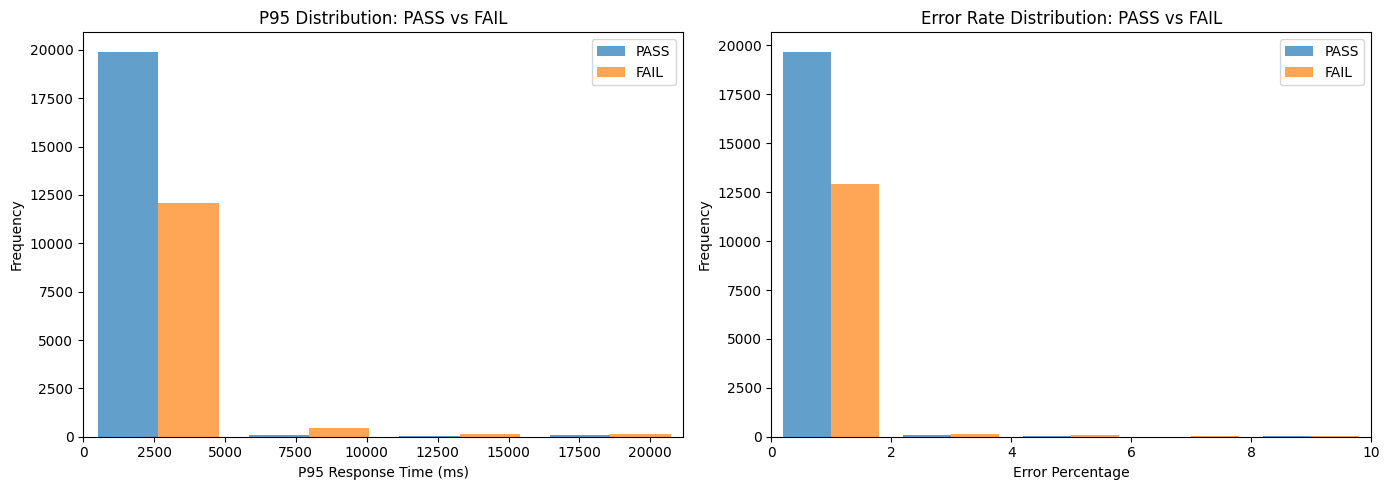


📊 Charts generated! Ask LLM to interpret:
ask_question('What do these distributions tell us about PASS vs FAIL tests?')


In [24]:
# Plot: P95 distribution by result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P95 by result
pass_data = df[df['exit_code'] == 1]['perc_95']
fail_data = df[df['exit_code'] != 1]['perc_95']

axes[0].hist([pass_data, fail_data], bins=50, label=['PASS', 'FAIL'], alpha=0.7)
axes[0].set_xlabel('P95 Response Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P95 Distribution: PASS vs FAIL')
axes[0].legend()
axes[0].set_xlim(0, pass_data.quantile(0.99))

# Error percentage by result
pass_err = df[df['exit_code'] == 1]['error_percentage']
fail_err = df[df['exit_code'] != 1]['error_percentage']

axes[1].hist([pass_err, fail_err], bins=50, label=['PASS', 'FAIL'], alpha=0.7)
axes[1].set_xlabel('Error Percentage')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Rate Distribution: PASS vs FAIL')
axes[1].legend()
axes[1].set_xlim(0, 10)  # Focus on 0-10% range

plt.tight_layout()
plt.show()

print("\n📊 Charts generated! Ask LLM to interpret:")
print("ask_question('What do these distributions tell us about PASS vs FAIL tests?')")

## 12. Export Conversation

Save your Q&A session for reference.

In [25]:
# Export conversation history
if conversation_history:
    print("💬 Conversation Summary:")
    print("=" * 80)
    
    for i, (question, answer) in enumerate(conversation_history, 1):
        print(f"\n**Q{i}:** {question}")
        print(f"**A{i}:** {answer[:500]}{'...' if len(answer) > 500 else ''}")
        print("-" * 80)
    
    print(f"\nTotal questions asked: {len(conversation_history)}")
else:
    print("No conversation history yet. Ask some questions first!")

💬 Conversation Summary:

**Q1:** What are the last 5 test runs and their results?
**A1:** Here are the last 5 test runs and their results:

| Test Name                  | P95   | Errors  | Txns | Result | End Time                        |
|----------------------------|-------|---------|------|--------|----------------------------------|
| LoadTest_20260304T060726Z  | 662ms | 0.0%    | 54   | PASS   | 2026-03-03 23:09:31.482435-08:00|
| LoadTest_20260302T113608Z  | 710ms | 0.0%    | 54   | PASS   | 2026-03-02 04:38:24.516272-08:00|
| LoadTest_20260302T051326Z  | 673ms | 0.0%    | 54  ...
--------------------------------------------------------------------------------

**Q2:** What patterns do you see in failed tests?
**A2:** Here are the last 10 failed test runs:

| Test Name                  | P95     | Errors  | Txns | Result | End Time                        |
|----------------------------|---------|---------|------|--------|----------------------------------|
| LoadTest_20251029T235

## 10. Tips & Tricks

**Good Questions to Ask:**
- "What's the average P95 for transaction X?"
- "Show me tests where error rate > 5%"
- "How does transaction Y compare between PASS and FAIL tests?"
- "What are common characteristics of failed tests?"
- "Is there a trend in test performance over time?"
- "Which transactions have the highest variance?"

**For Follow-up Questions:**
- The conversation history is maintained
- Previous context helps with follow-ups
- You can ask "Why?" or "Explain more" for clarification

**Data Manipulation:**
- Use pandas to filter/aggregate data
- Pass results to `ask_question()` for LLM interpretation
- Combine visualizations with LLM insights